III. PROCEDURES

In [3]:
import sys
!{sys.executable} -m pip install undetected-chromedriver

In [1]:
%pip install matplotlib pillow

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

In [3]:
import requests, bs4, lxml, pandas
print("All libraries successfully imported!")


All libraries successfully imported!


In [15]:
#STEP 3: Send an HTTP GET Request

url = "https://towardsdatascience.com/"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

response = requests.get(url, headers=headers)

print("--- Initiating Contact ---")
print(f"Status Code: {response.status_code}")

print("HTML Content Preview (First 500 characters):")
print(response.text[:500])
print("---")


--- Initiating Contact ---
Status Code: 200
HTML Content Preview (First 500 characters):
<!DOCTYPE html>
<html lang="en-US">
<head>
	<meta charset="UTF-8" />
	<script src="https://h030.towardsdatascience.com/script.js"></script><!-- Google Tag Manager -->
<script>
	(function (w, d, s, l, i) {
		w[l] = w[l] || [];
		w[l].push({
			'gtm.start': new Date().getTime(),
			event: 'gtm.js'
		});
		var f = d.getElementsByTagName(s)[0],
			j = d.createElement(s),
			dl = l != 'dataLayer' ? '&l=' + l : '';
		j.async = true;
		j.src =
			'https://www.googletagmanager.com/gtm.js?id=' + i + dl;

---


In [14]:
#STEP 4: Parse HTML Content
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com//"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
response.raise_for_status() 
html_content = response.text

soup = BeautifulSoup(html_content, 'lxml') 

print("--- Parsing HTML Content ---")
if soup.title:
    print(f"Parsed Page Title: {soup.title.text.strip()}")
else:
    print("Page title not found. HTML parsing might need adjustment.")
print("---")

--- Parsing HTML Content ---
Parsed Page Title: Quotes to Scrape
---


In [21]:
#STEP 5: Locate and Extract Specific Data Elements
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

url = "https://en.wikipedia.org/wiki/Main_Page"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

print(f"Attempting to scrape: {url}")
try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status() 
    soup = BeautifulSoup(response.text, 'lxml')
    article_links_data = []

    in_the_news_div = soup.find('div', id='mp-itn')

    if in_the_news_div:
        print("\n--- From 'In the news' section ---")
        links = in_the_news_div.find_all('a', href=True)
        for link in links:
            title_text = link.text.strip()
            href = link['href']

            if title_text and href.startswith('/wiki/') and ':' not in href:
                absolute_url = urljoin(url, href)
                if not any(data['url'] == absolute_url for data in article_links_data):
                    article_links_data.append({
                        'title': title_text,
                        'url': absolute_url
                    })

    on_this_day_div = soup.find('div', id='mp-otd')
    if on_this_day_div:
        print("\n--- From 'On this day' section ---")
        links = on_this_day_div.find_all('a', href=True)
        for link in links:
            title_text = link.text.strip()
            href = link['href']
            if title_text and href.startswith('/wiki/') and ':' not in href:
                absolute_url = urljoin(url, href)
                if not any(data['url'] == absolute_url for data in article_links_data):
                    article_links_data.append({
                        'title': title_text,
                        'url': absolute_url
                    })

    if article_links_data:
        print("\nExtracted Article Titles and URLs (First 10 from all sections):")
        for i, article in enumerate(article_links_data[:10]):
            print(f"- Title: '{article['title']}'")
            print(f" URL: {article['url']}")
    else:
        print("\nNo article links found in the targeted sections ('In the news','On this day').")
        print("The HTML structure might have changed, or the selectors need adjustment.")

except requests.exceptions.RequestException as e:
    print(f"\nError fetching URL {url}: {e}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")
print("---")


Attempting to scrape: https://en.wikipedia.org/wiki/Main_Page

--- From 'In the news' section ---

--- From 'On this day' section ---

Extracted Article Titles and URLs (First 10 from all sections):
- Title: 'Progressive Bulgaria'
 URL: https://en.wikipedia.org/wiki/Progressive_Bulgaria
- Title: 'Rumen Radev'
 URL: https://en.wikipedia.org/wiki/Rumen_Radev
- Title: 'National Assembly'
 URL: https://en.wikipedia.org/wiki/National_Assembly_(Bulgaria)
- Title: 'the parliamentary elections'
 URL: https://en.wikipedia.org/wiki/2026_Bulgarian_parliamentary_election
- Title: 'the ongoing Bulgarian political crisis'
 URL: https://en.wikipedia.org/wiki/2021%E2%80%93present_Bulgarian_political_crisis
- Title: 'in Siverek'
 URL: https://en.wikipedia.org/wiki/2026_Siverek_school_shooting
- Title: 'in Onikişubat'
 URL: https://en.wikipedia.org/wiki/2026_Oniki%C5%9Fubat_school_shooting
- Title: 'Romuald Wadagni'
 URL: https://en.wikipedia.org/wiki/Romuald_Wadagni
- Title: 'the Beninese presidential 

In [22]:
#STEP 6: Extract Data from HTML Tables

import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
url = "https://en.wikipedia.org/wiki/List_of_datasets_for_machine_learning_research"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'lxml') 

print("--- PROCEDURE 6: Extract Data from HTML Tables ---")

target_table = soup.find('table', class_='wikitable')
if target_table:
    table_headers = [th.text.strip() for th in target_table.find('tr').find_all('th')]
    print(f"Table Headers (First 5): {table_headers[:5]}")

    table_data = []
    for row in target_table.find_all('tr')[1:6]: 
        cells = row.find_all(['td', 'th'])
        cell_texts = [cell.text.strip() for cell in cells]
        table_data.append(cell_texts)

    print("\nFirst 5 Data Rows (Raw Lists):")
    for i, row in enumerate(table_data):
        print(f"Row {i+1}: {row[:5]}...")

        try:
            df = pd.DataFrame(table_data,
columns=table_headers[:len(table_data[0])])
            print("\nDataFrame Representation (Head of first 3 rows):")
            print(df.head(3).to_string())
        except ValueError as e:
            print(f"\nCould not create DataFrame. Column count mismatch: {e}")
    else:
        print("No data rows found in the table.")

else:
    print("Target table with class 'wikitable' not found on the page.")
print("---")


--- PROCEDURE 6: Extract Data from HTML Tables ---
Table Headers (First 5): ['Type', 'Subtypes']

First 5 Data Rows (Raw Lists):
Row 1: ['Specific category', 'Finance, Economics, Commerce, Societal, Health, Academy, Sports, Food, Agriculture, Travel, Geospatial, Political, Consumer, Transport,  Logistics, Environmental, Real-Estate, Legal, Entertainment, Energy, Hospitality']...

DataFrame Representation (Head of first 3 rows):
                Type                                                                                                                                                                                                                   Subtypes
0  Specific category  Finance, Economics, Commerce, Societal, Health, Academy, Sports, Food, Agriculture, Travel, Geospatial, Political, Consumer, Transport,  Logistics, Environmental, Real-Estate, Legal, Entertainment, Energy, Hospitality
1              Scope                                                                    

In [2]:
#STEP 7: Handle Pagination

import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
import time

print("--- PROCEDURE 7: Handle Pagination (Quotes to Scrape) ---")

start_url = "http://quotes.toscrape.com/"
base_domain = urlparse(start_url).netloc
all_quotes = [] 
pages_to_collect = 3 

current_page_url = start_url
page_counter = 0

while page_counter < pages_to_collect:
    print(f"\nAttempting to fetch page {page_counter + 1}: {current_page_url}")
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
        response = requests.get(current_page_url, headers=headers, timeout=10)
        response.raise_for_status() # Check for HTTP errors (e.g., 404, 500)
        soup = BeautifulSoup(response.text, 'lxml') 

        quote_elements = soup.find_all('div', class_='quote')

        if quote_elements:
            for quote_item in quote_elements:
                text = quote_item.find('span', class_='text').text.strip()
                author = quote_item.find('small', class_='author').text.strip()
                all_quotes.append({'text': text, 'author': author})
            print(f"Collected {len(quote_elements)} quotes from this page.")
        else:
            print("No quote elements found on this page. Stopping.")
            break 
    
        next_li = soup.find('li', class_='next')
        if next_li:
            next_link_element = next_li.find('a', href=True)
            if next_link_element:
                next_page_relative_url = next_link_element['href']
                current_page_url = urljoin(start_url, next_page_relative_url)
                page_counter += 1
                time.sleep(1)

            else:
                print("Next page link <a> tag not found within 'next' li.Stopping.")
                break
        else:
            print("No 'next' pagination link found. Assuming last page.")
            break 
            
    except requests.exceptions.RequestException as e:
        print(f"ERROR (Network/HTTP): Could not fetch {current_page_url}: {e}")
        break # Stop on error
    except Exception as e:
        print(f"ERROR (Unexpected): An unhandled error occurred for {current_page_url}: {e}")
        break
        
print(f"\n--- Total Quotes Collected Across {page_counter} pages: {len(all_quotes)} ---")
print("First 5 Collected Quotes (Sample):")
for i, quote in enumerate(all_quotes[:5]):
    print(f"- \"{quote['text']}\" - {quote['author']}")
print("--- End of Procedure ---")

--- PROCEDURE 7: Handle Pagination (Quotes to Scrape) ---

Attempting to fetch page 1: http://quotes.toscrape.com/
Collected 10 quotes from this page.

Attempting to fetch page 2: http://quotes.toscrape.com/page/2/
Collected 10 quotes from this page.

Attempting to fetch page 3: http://quotes.toscrape.com/page/3/
Collected 10 quotes from this page.

--- Total Quotes Collected Across 3 pages: 30 ---
First 5 Collected Quotes (Sample):
- "“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”" - Albert Einstein
- "“It is our choices, Harry, that show what we truly are, far more than our abilities.”" - J.K. Rowling
- "“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”" - Albert Einstein
- "“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”" - Jane Austen
- "“Imperfection is beauty, madness is geni

In [3]:
#STEP 8: Clean and Standardize Extracted Data

import requests
from bs4 import BeautifulSoup
import re
import pandas as pd

url = "https://en.wikipedia.org/wiki/Comparison_of_deep_learning_software"
headers = {'User-Agent': 'Mozilla/5.0'}

print("--- PROCEDURE 8: Clean and Standardize Extracted Data (Revised for Wikipedia Table) ---")

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    table = soup.find('table', class_='wikitable')

    if table:
        header_cells = table.find('tr').find_all('th')
        headers_text = [th.text.strip() for th in header_cells]

        software_idx = headers_text.index('Software') if 'Software' in headers_text else -1
        creator_idx = headers_text.index('Creator') if 'Creator' in headers_text else -1
        initial_release_idx = headers_text.index('Initial release') if 'Initial release' in headers_text else -1

        required_indices = [software_idx, creator_idx, initial_release_idx]
        required_names = ['Software', 'Creator', 'Initial release']

        if any(idx == -1 for idx in required_indices):
            print("ERROR: One or more required columns are still missing in the table headers based on current revision.")
            print(f"Expected: {required_names}")
            print("Found headers:", headers_text)
            exit() 
        
        cleaned_data_records = []
        data_rows = table.find_all('tr')[1:] 

        for row_num, row in enumerate(data_rows):
            cols = row.find_all('td')

            if len(cols) > max(required_indices):

                software_name = cols[software_idx].text.strip()
                creator_name = cols[creator_idx].text.strip()
                raw_initial_release = cols[initial_release_idx].text.strip()

                clean_initial_release = re.sub(r'\[.*?\]', '', raw_initial_release).strip()

                cleaned_data_records.append({
                    'Software': software_name,
                    'Creator': creator_name,
                    'Initial_Release_Date': clean_initial_release
                })
            else:
                print(f"Skipping row {row_num + 1} due to insufficient columns or unexpected structure.")

        print("Cleaned and Standardized Data (First 5 records):")
        for record in cleaned_data_records[:5]:
            print(record)

        df_cleaned = pd.DataFrame(cleaned_data_records)
        print("\nDataFrame Info after Cleaning:")
        df_cleaned.info()
        print("\nDataFrame Head (cleaned data):")
        print(df_cleaned.head().to_string())

    else:
        print("Table with class 'wikitable' not found. Check URL or table class on the page.")
except requests.exceptions.RequestException as e:
    print(f"ERROR (Network/HTTP): Could not fetch {url}: {e}")
except Exception as e:
    print(f"ERROR (Unexpected): An unhandled error occurred: {e}")
finally:
    print("--- End of Procedure ---")

--- PROCEDURE 8: Clean and Standardize Extracted Data (Revised for Wikipedia Table) ---
Skipping row 30 due to insufficient columns or unexpected structure.
Cleaned and Standardized Data (First 5 records):
{'Software': 'BigDL', 'Creator': 'Jason Dai (Intel)', 'Initial_Release_Date': '2016'}
{'Software': 'Caffe', 'Creator': 'Berkeley Vision and Learning Center', 'Initial_Release_Date': '2013'}
{'Software': 'Chainer', 'Creator': 'Preferred Networks', 'Initial_Release_Date': '2015'}
{'Software': 'Deeplearning4j', 'Creator': 'Skymind engineering team; Deeplearning4j community; originally Adam Gibson', 'Initial_Release_Date': '2014'}
{'Software': 'DeepSpeed', 'Creator': 'Microsoft', 'Initial_Release_Date': '2019'}

DataFrame Info after Cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Software              29 non-null     str  
 1   Creato

In [5]:
#STEP 9: Implement Error Handling and Robustness

import requests
from bs4 import BeautifulSoup

print("--- PROCEDURE 9: Implement Error Handling and Robustness ---")

test_scenarios = {

    "valid_article_page":
"https://en.wikipedia.org/wiki/Artificial_intelligence",
    "non_existent_article": "http://httpbin.org/status/404",
    "slow_server_sim": "http://httpbin.org/delay/6",
    "invalid_domain_connect": "http://this.domain.does.not.resolve.abc" 
}
for scenario_name, test_url in test_scenarios.items():
    print(f"\nTesting Scenario: '{scenario_name}' at {test_url}")
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(test_url, headers=headers, timeout=5)

        response.raise_for_status()

        soup = BeautifulSoup(response.text, 'lxml')

        if scenario_name == "valid_article_page":
            main_title_element = soup.find('h1', id='firstHeading')
        else:
            main_title_element = soup.find('h1') 

        if main_title_element:
            print(f"SUCCESS: Fetched and found title: '{main_title_element.text.strip()[:100]}...'")
        else:
            print("SUCCESS (with caveat): Fetched page, but main title element not found.")
    
    except requests.exceptions.HTTPError as e:
        print(f"ERROR (HTTP): Status Code {e.response.status_code} for {test_url}. Reason: {e.response.reason}")
    except requests.exceptions.ConnectionError as e:
        print(f"ERROR (Connection): Could not establish connection to {test_url}. Details: {e}")
    except requests.exceptions.Timeout as e:
        print(f"ERROR (Timeout): Request to {test_url} timed out after 5 seconds. Details: {e}")
    except requests.exceptions.RequestException as e:
        print(f"ERROR (General Request): An unexpected request error occurred for {test_url}. Details: {e}")
    except Exception as e:
        print(f"ERROR (Unexpected): An unhandled error occurred for {test_url}. Details: {e}")
print("---")



--- PROCEDURE 9: Implement Error Handling and Robustness ---

Testing Scenario: 'valid_article_page' at https://en.wikipedia.org/wiki/Artificial_intelligence
SUCCESS: Fetched and found title: 'Artificial intelligence...'

Testing Scenario: 'non_existent_article' at http://httpbin.org/status/404
ERROR (HTTP): Status Code 404 for http://httpbin.org/status/404. Reason: NOT FOUND

Testing Scenario: 'slow_server_sim' at http://httpbin.org/delay/6
ERROR (Timeout): Request to http://httpbin.org/delay/6 timed out after 5 seconds. Details: HTTPConnectionPool(host='httpbin.org', port=80): Read timed out. (read timeout=5)

Testing Scenario: 'invalid_domain_connect' at http://this.domain.does.not.resolve.abc
ERROR (Connection): Could not establish connection to http://this.domain.does.not.resolve.abc. Details: HTTPConnectionPool(host='this.domain.does.not.resolve.abc', port=80): Max retries exceeded with url: / (Caused by NameResolutionError("HTTPConnection(host='this.domain.does.not.resolve.abc',

In [12]:
#STEP 10: Store the Extracted Data

import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import os 
import re 
import sqlite3 

print("\n--- PROCEDURE 10: Store the Extracted Data ---")

url = "https://en.wikipedia.org/wiki/Comparison_of_deep_learning_software"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=10) 
    response.raise_for_status() 
    soup = BeautifulSoup(response.text, 'lxml') 

    final_data_to_save = []
    table = soup.find('table', class_='wikitable')

    if table:
        table_headers_raw = [th.text.strip() for th in table.find('tr').find_all('th')]

        table_headers = [re.sub(r'\[.*?\]|\s\(.*?\)', '', h).replace(' ', '_').strip() for h in table_headers_raw]
        data_rows = table.find_all('tr')[1:]

        for i, row in enumerate(data_rows[:15]):
            cols = row.find_all('td') 
            row_data = {}

            for j, col in enumerate(cols):
                if j < len(table_headers): 
                    header_key = table_headers[j]
                    row_data[header_key] = col.text.strip() 

            if row_data: 

                final_data_to_save.append(row_data)
    else:
        print("ERROR: Table with class 'wikitable' not found on the page. Check URL or table class.")

    if final_data_to_save:
        df_output = pd.DataFrame(final_data_to_save)
        print("\n--- Data Ready for Archiving (DataFrame Head) ---")
        print(df_output.head().to_string()) 
        
        csv_file_path = 'deep_learning_software_comparison.csv'
        df_output.to_csv(csv_file_path, index=False, encoding='utf-8')

        print(f"\nData successfully saved to: {csv_file_path} (CSV format)")

        json_file_path = 'deep_learning_software_comparison.json'

        df_output.to_json(json_file_path, orient='records', indent=4)
        print(f"Data successfully saved to: {json_file_path} (JSON format)")
  
        db_file_path = 'deep_learning_software_comparison.db'
        table_name = 'dl_software_comparison' 

        conn = None
        try:
            conn = sqlite3.connect(db_file_path) 

            df_output.to_sql(table_name, conn, if_exists='replace', index=False)
            print(f"Data successfully saved to: {db_file_path} (SQLite database, table: '{table_name}')")
        except Exception as db_err:
            print(f"ERROR (SQLite): Could not save data to SQLite: {db_err}")
        finally:
            if conn:
                conn.close() 

        all_files_exist =  os.path.exists(csv_file_path) and os.path.exists(json_file_path) and os.path.exists(db_file_path)
        
        if all_files_exist:
            print("\nVerification: CSV, JSON, and SQLite files are all present in the directory.")
        else:
            print("\nVerification Failed: One or more files were not found after saving.")
    else:
        print("No data collected to proceed with storage.")

except requests.exceptions.RequestException as e:
    print(f"ERROR (Network/HTTP): Could not fetch {url}: {e}")
except Exception as e:
    print(f"ERROR (Unexpected): An unhandled error occurred: {e}")


--- PROCEDURE 10: Store the Extracted Data ---

--- Data Ready for Archiving (DataFrame Head) ---
         Software                                                                     Creator Initial_release Software_license Open_source                                         Platform         Written_in                                     Interface OpenMP_support        OpenCL_support CUDA_support ROCm_support Automatic_differentiation Has_pretrained_models Recurrent_nets Convolutional_nets RBM/DBNs Parallel_execution(multi_node) Actively_developed
0           BigDL                                                           Jason Dai (Intel)            2016       Apache 2.0         Yes                                     Apache Spark              Scala                                 Scala, Python                                                No           No                                             Yes            Yes                Yes                                               

IV. DATA AND OBSERVATION

In [13]:
#1 
import requests

url = "https://en.wikipedia.org/wiki/Web_scraping"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=5)
    print(f"HTTP Status Code: {response.status_code}")
except requests.exceptions.RequestException as e:
    print(f"Error fetching URL: {e}")

HTTP Status Code: 200


In [14]:
#2
import requests
from bs4 import BeautifulSoup
url = "https://en.wikipedia.org/wiki/Web_scraping"
headers = {'User-Agent': 'Mozilla/5.0'}
try:
    response = requests.get(url, headers=headers, timeout=5)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    print(f"Page Title (from <title> tag): {soup.title.text}")
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

Page Title (from <title> tag): Web scraping - Wikipedia


In [15]:
#3
import requests
from bs4 import BeautifulSoup

url ="https://en.wikipedia.org/wiki/Artificial_intelligence"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=5)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    main_heading = soup.find('h1', id='firstHeading')
    if main_heading:
        print(f"Main Heading: '{main_heading.text.strip()}'")
    else:
        print("Main heading (h1 with id='firstHeading') not found.")
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

Main Heading: 'Artificial intelligence'


In [17]:
#4
import requests
from bs4 import BeautifulSoup
url = "https://en.wikipedia.org/wiki/Artificial_intelligence"
headers = {'User-Agent': 'Mozilla/5.0'}
try:
    response = requests.get(url, headers=headers, timeout=5)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    content_div = soup.find('div', id='mw-contenttext')
    first_paragraph = None
    if content_div:
        paragraphs = content_div.find_all('p')
        for p in paragraphs:
            text = p.text.strip()
            if text and not p.find_parent('table', class_='infobox'):
                first_paragraph = text
                break
    if first_paragraph:
        print(f"First Paragraph (truncated): '{first_paragraph[:150]}...'")
    else:
        print("First meaningful paragraph notfound.")
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

First meaningful paragraph notfound.


In [19]:
#5
import requests
from bs4 import BeautifulSoup
url = "http://quotes.toscrape.com/" 
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

try:
    response = requests.get(url, headers=headers, timeout=5)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')

    first_quote_div = soup.find('div', class_='quote')

    if first_quote_div:
        quote_text_element = first_quote_div.find('span', class_='text')   
        author_element = first_quote_div.find('small', class_='author')

        if quote_text_element and author_element:
            quote = quote_text_element.text.strip()
            author = author_element.text.strip()
            print(f"Sample Quote: '{quote}'")
            print(f"Sample Author: {author}")
        else:
            print("No usable quote text or author element found within the first quote div.")
    else:
        print("No quote div found. The website structure may have changed, or a different selector is needed.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching the page: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Sample Quote: '“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”'
Sample Author: Albert Einstein


In [20]:
#6
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')

    first_quote_div = soup.find('div', class_='quote')

    if first_quote_div:
        author_element = first_quote_div.find('small', class_='author')
        if author_element:
            author_name = author_element.text.strip()
            print(f"Author of the first quote: '{author_name}'")
        else:
            print("Author element not found within the first quote div (class='author').")
    else:
        print("First quote container (div with class 'quote') not found. The website structure may have changed, or a different selector is needed.")

except requests.exceptions.RequestException as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Author of the first quote: 'Albert Einstein'


In [22]:
#7
import requests
from bs4 import BeautifulSoup
url = "http://quotes.toscrape.com/"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status() 
    soup = BeautifulSoup(response.text, 'lxml')

    all_quote_divs = soup.find_all('div', class_='quote')

    if all_quote_divs:
        print("Authors found on the page:")
        authors_list = []
        for i, quote_div in enumerate(all_quote_divs):

            author_element = quote_div.find('small', class_='author')
            if author_element:
                author_name = author_element.text.strip()
                authors_list.append(author_name)
                print(f"- {author_name}")
            else:
                print(f"- Author not found for quote #{i+1}.")

        print(f"\nTotal unique authors found: {len(set(authors_list))}")
    else:
        print("No quote containers (divs with class 'quote') found on the page.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching the page: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Authors found on the page:
- Albert Einstein
- J.K. Rowling
- Albert Einstein
- Jane Austen
- Marilyn Monroe
- Albert Einstein
- André Gide
- Thomas A. Edison
- Eleanor Roosevelt
- Steve Martin

Total unique authors found: 8


In [23]:
#8
import requests
from bs4 import BeautifulSoup
import re 

url = "https://en.wikipedia.org/wiki/List_of_countries_by_population"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    table = soup.find('table', class_='wikitable')
    if table:
        header_cells = table.find('tr').find_all('th')
        headers_text = [th.text.strip() for th in header_cells]

        population_idx = -1
        for i, header in enumerate(headers_text):
            if 'Population' in header:
                population_idx = i
                break

        if population_idx != -1:
            first_data_row = table.find_all('tr')[1]
            cols = first_data_row.find_all('td')

            if len(cols) > population_idx:
                raw_population = cols[population_idx].text.strip()
                print(f"Raw Population String (e.g., World population): '{raw_population}'")

            else:
                print("Population column not found in the first data row (index out of bounds).")
        else:
            print("Population header not found in table. Check header text for variations (e.g.,'Population (July 2024 est.)').")
    else:
        print("Table with class 'wikitable' not found on the page.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching the page: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Raw Population String (e.g., World population): '8,232,000,000'


In [24]:
#9
import pandas as pd

items = soup.select(".thumbnail")
data = []
for it in items:
    data.append({
        "name": it.select_one(".title")["title"],
        "price": it.select_one(".price").text
    })
    
df = pd.DataFrame(data)
df.to_csv("laptops.csv", index=False)
print("Saved laptops.csv")


Saved laptops.csv


In [25]:
#10
import requests
url = "http://httpbin.org/delay/6"
headers = {'User-Agent': 'Mozilla/5.0'}
try:
    response = requests.get(url, headers=headers, timeout=5)
    response.raise_for_status()
    print("SUCCESS: Page fetched (unexpected for timeout).")
except requests.exceptions.Timeout as e:
    print(f"ERROR (Timeout): Request to {url} timed out after 5 seconds. Details: {e}")
except requests.exceptions.RequestException as e:
    print(f"ERROR (General Request): {e}")

ERROR (Timeout): Request to http://httpbin.org/delay/6 timed out after 5 seconds. Details: HTTPConnectionPool(host='httpbin.org', port=80): Read timed out. (read timeout=5)


In [26]:
#11
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
url = "http://quotes.toscrape.com/"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

scraped_data = []
response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'lxml')

all_quote_divs = soup.find_all('div', class_='quote')

for quote_div in all_quote_divs:
    quote_text_element = quote_div.find('span', class_='text')
    author_element = quote_div.find('small', class_='author')
    quote = quote_text_element.text.strip() if quote_text_element else "N/A"
    author = author_element.text.strip() if author_element else "N/A"

    scraped_data.append({
        'Quote': quote,
        'Author': author
    })

df_scraped = pd.DataFrame(scraped_data)

csv_file_path = 'web_scraped_quotes.csv'

df_scraped.to_csv(csv_file_path, index=False, encoding='utf-8')

print(csv_file_path)


web_scraped_quotes.csv


In [27]:
#12
import requests
from bs4 import BeautifulSoup
import json # Import the json module
import os

url = "http://quotes.toscrape.com/"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
scraped_data = []

response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'lxml')

all_quote_divs = soup.find_all('div',
class_='quote')

for quote_div in all_quote_divs:
    quote_text_element = quote_div.find('span', class_='text')
    author_element = quote_div.find('small', class_='author')

    quote = quote_text_element.text.strip() if quote_text_element else "N/A"
    author = author_element.text.strip() if author_element else "N/A"

    scraped_data.append({
        'quote': quote,
        'author': author
    })

json_file_path = 'web_scraped_quotes.json'

with open(json_file_path, 'w', encoding='utf-8') as f:
    json.dump(scraped_data, f, ensure_ascii=False, indent=4) 

print(json_file_path)

web_scraped_quotes.json


In [31]:
#13
import requests
from bs4 import BeautifulSoup
import sqlite3 # Import the sqlite3 module
import os

url = "http://quotes.toscrape.com/"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

scraped_data = []

response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'lxml')

all_quote_divs = soup.find_all('div', class_='quote')

for quote_div in all_quote_divs:
    quote_text_element = quote_div.find('span', class_='text')
    author_element = quote_div.find('small', class_='author')

    quote = quote_text_element.text.strip() if quote_text_element else "N/A"
    author = author_element.text.strip() if author_element else "N/A"

    scraped_data.append({
        'quote': quote,
        'author': author
    })

db_file_path = 'web_scraped_quotes.db' 

conn = sqlite3.connect(db_file_path) 
cursor = conn.cursor() 

cursor.execute(''' CREATE TABLE IF NOT EXISTS quotes ( id INTEGER PRIMARY KEY AUTOINCREMENT, quote TEXT NOT NULL,author TEXT NOT NULL)''')

for item in scraped_data:
    cursor.execute("INSERT INTO quotes (quote,author) VALUES (?, ?)", (item['quote'],item['author']))

conn.commit() 
conn.close()
print(db_file_path)

web_scraped_quotes.db


In [34]:

#14
import pandas as pd
import sqlite3
import os

db_file_path = 'web_scraped_quotes.db'
table_name = 'quotes'

if os.path.exists(db_file_path):
    conn = sqlite3.connect(db_file_path)
    df_read = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    print("\nData read from SQLite ('web_scraped_quotes.db'):")
    print(df_read.to_string())

    
else:
    print(f"SQLite database '{db_file_path}' not found. Please ensure the data was stored to SQLite first.")


Data read from SQLite ('web_scraped_quotes.db'):
   id                                                                                                                                quote             author
0   1                  “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”    Albert Einstein
1   2                                                “It is our choices, Harry, that show what we truly are, far more than our abilities.”       J.K. Rowling
2   3  “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”    Albert Einstein
3   4                             “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”        Jane Austen
4   5                      “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”     Marilyn Monroe
5 

In [35]:
#15
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')

    quote_elements = soup.find_all('div', class_='quote')

    if quote_elements:
        print(f"Found {len(quote_elements)} quotes on the first page.")
        for i, quote_item in enumerate(quote_elements[:2]):
            text = quote_item.find('span', class_='text').text.strip()
            author = quote_item.find('small', class_='author').text.strip()
            print(f"Quote {i+1}: \"{text[:70]}...\" - {author}")
    else:
        print("No quotes found on the first page.")
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

Found 10 quotes on the first page.
Quote 1: "“The world as we have created it is a process of our thinking. It cann..." - Albert Einstein
Quote 2: "“It is our choices, Harry, that show what we truly are, far more than ..." - J.K. Rowling


In [36]:
#16
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
url = "http://quotes.toscrape.com/"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    next_li = soup.find('li', class_='next')

    if next_li:
        next_link_element = next_li.find('a',href=True)
        if next_link_element:
            next_page_relative_url = next_link_element['href'] 
            full_next_page_url = urljoin(url, next_page_relative_url)
            print(f"Found 'Next Page' link: {full_next_page_url}")
 
        else:
            print("Next page <a> tag not found within 'next' li.")
    else:
        print("No 'next' pagination li found (might be on the last page).")

except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

Found 'Next Page' link: http://quotes.toscrape.com/page/2/


In [37]:
#17
import requests
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/Comparison_of_deep_learning_software"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')

    table = soup.find('table', class_='wikitable')
    if table:
        header_cells = table.find('tr').find_all('th')
        raw_headers = [th.text.strip() for th in header_cells]
        print(f"Raw Headers: {raw_headers}")
    else:
        print("Table not found.")
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

Raw Headers: ['Software', 'Creator', 'Initial release', 'Software license[a]', 'Open source', 'Platform', 'Written in', 'Interface', 'OpenMP support', 'OpenCL support', 'CUDA support', 'ROCm support[1]', 'Automatic differentiation[2]', 'Has pretrained models', 'Recurrent nets', 'Convolutional nets', 'RBM/DBNs', 'Parallel execution(multi node)', 'Actively developed']


In [39]:
#18
import requests
from bs4 import BeautifulSoup
import re

url = "https://en.wikipedia.org/wiki/Comparison_of_deep_learning_software"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

raw_headers = []

response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'lxml')

table = soup.find('table', class_='wikitable')

header_cells = table.find('tr').find_all('th')
raw_headers = [th.text.strip() for th in header_cells]
print(f"Raw Headers from Web Scraping: {raw_headers}")

standardized_headers = [re.sub(r'\[.*?\]|\s\(.*?\)', '', h).replace(' ', '_').strip() for h in raw_headers]
print(f"Standardized Headers: {standardized_headers}")


Raw Headers from Web Scraping: ['Software', 'Creator', 'Initial release', 'Software license[a]', 'Open source', 'Platform', 'Written in', 'Interface', 'OpenMP support', 'OpenCL support', 'CUDA support', 'ROCm support[1]', 'Automatic differentiation[2]', 'Has pretrained models', 'Recurrent nets', 'Convolutional nets', 'RBM/DBNs', 'Parallel execution(multi node)', 'Actively developed']
Standardized Headers: ['Software', 'Creator', 'Initial_release', 'Software_license', 'Open_source', 'Platform', 'Written_in', 'Interface', 'OpenMP_support', 'OpenCL_support', 'CUDA_support', 'ROCm_support', 'Automatic_differentiation', 'Has_pretrained_models', 'Recurrent_nets', 'Convolutional_nets', 'RBM/DBNs', 'Parallel_execution(multi_node)', 'Actively_developed']


In [ ]:
#19
import requests
url = "http://this.domain.does.not.resolve.abc"

try:
    response = requests.get(url, timeout=5)
    response.raise_for_status()
    
except requests.exceptions.ConnectionError as e:
    print(f"ERROR (Connection): Could not establish connection to {url}. Details: {e}")

ERROR (Connection): Could not establish connection to http://this.domain.does.not.resolve.abc. Details: HTTPConnectionPool(host='this.domain.does.not.resolve.abc', port=80): Max retries exceeded with url: / (Caused by NameResolutionError("HTTPConnection(host='this.domain.does.not.resolve.abc', port=80): Failed to resolve 'this.domain.does.not.resolve.abc' ([Errno 11001] getaddrinfo failed)"))


In [48]:
#20
import requests
from bs4 import BeautifulSoup
import re
url = "https://en.wikipedia.org/wiki/Artificial_intelligence"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')

    last_modified_element = soup.find('li', id='footer-info-lastmod')
    if last_modified_element:
        raw_text = last_modified_element.text.strip()
        date_match = re.search(r'on (\d{1,2} \w+ \d{4})', raw_text)
        if date_match:
            clean_date = date_match.group(1)
            print(f"Last Modified Date: '{clean_date}'")
        else:
            print(f"Last Modified Date (raw, unable to parse): '{raw_text}'")
    else:
        print("Last modified element not found.")
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")

Last Modified Date: '22 April 2026'


E. ADDITIONAL EXERCISES

In [ ]:
#1. Daily Weather Logger Simulation

import os
import time
import logging
from datetime import datetime
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from datetime import datetime, timedelta
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

class EnterpriseWeatherScraper:
    """
    A production-grade web scraper utilizing Selenium CDP injection 
    to bypass automated detection without relying on unstable patched drivers.
    """
    def __init__(self, target_url: str):
        self.target_url = target_url
        self.csv_file = "weather_data.csv"
        
        self.driver = self._build_stealth_driver()

    def _build_stealth_driver(self) -> webdriver.Chrome:
        """Constructs a standard WebDriver with advanced evasion techniques."""
        logging.info("Initializing stealth WebDriver engine...")
        options = Options()
        
        
        options.add_argument("--start-maximized")
        options.add_argument("--disable-blink-features=AutomationControlled")
        options.add_experimental_option("excludeSwitches", ["enable-automation"])
        options.add_experimental_option('useAutomationExtension', False)
        
        
        driver = webdriver.Chrome(options=options)
        
        
        driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
            "source": "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
        })
        return driver

    def extract_historic_data(self, city_name: str):
        """Executes the extraction pipeline with dynamic element waiting."""
        logging.info(f"Connecting to target node: {self.target_url}")
        try:
            self.driver.get(self.target_url)
            
            
            logging.info("Awaiting DOM rendering and data population...")
            WebDriverWait(self.driver, 15).until(
                EC.presence_of_element_located((By.ID, "wt-his"))
            )
            
            
            self.driver.execute_script("window.scrollTo(0, 500);")
            
            
            soup = BeautifulSoup(self.driver.page_source, 'lxml')
            
           
            extracted_payload = self._parse_historic_table(soup, city_name)
            
            if extracted_payload:
                self._commit_to_storage(extracted_payload)
                logging.info("Cycle complete. Data safely committed to disk.")
            else:
                logging.warning("Failed to extract meaningful data from the DOM.")

        except Exception as e:
            logging.error(f"Pipeline Failure: {str(e)}", exc_info=True)

    def _parse_historic_table(self, soup: BeautifulSoup, city: str) -> dict:
        """Parses the specific HTML structure of the timeanddate /historic page."""
        
        # Target the primary historic data table
        historic_table = soup.find('table', id='wt-his')
        if not historic_table:
            return {}

        tbody = historic_table.find('tbody')
        if not tbody:
            return {}

        
        rows = tbody.find_all('tr')
        if not rows:
            return {}

        latest_row = rows[0]
        cols = latest_row.find_all(['th', 'td'])
        
        
        try:
            return {
                'timestamp_scraped': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                'city': city,
                
                'recorded_time': cols[0].text.strip() if len(cols) > 0 else "N/A",
                'temperature': cols[1].text.replace('\xa0', ' ').strip() if len(cols) > 1 else "N/A",
                'condition': cols[2].text.strip() if len(cols) > 2 else "N/A",
                'wind': cols[3].text.replace('\xa0', ' ').strip() if len(cols) > 3 else "N/A",
                'humidity': cols[5].text.strip() if len(cols) > 5 else "N/A",
                'pressure': cols[6].text.strip() if len(cols) > 6 else "N/A",
                'visibility': cols[7].text.strip() if len(cols) > 7 else "N/A"
            }
        except Exception as e:
            logging.error(f"DOM mapping error: {e}")
            return {}

    def _commit_to_storage(self, data: dict):
        """Appends the standardized dictionary payload to a CSV."""
        df = pd.DataFrame([data])
        file_exists = os.path.isfile(self.csv_file)
        df.to_csv(self.csv_file, mode='a', index=False, header=not file_exists, encoding='utf-8')

    def teardown(self):
        """Graceful teardown sequence to prevent memory leaks."""
        logging.info("Terminating WebDriver instance.")
        self.driver.quit()



if __name__ == "__main__":
    TARGET_CITY = "Quezon City"
    BASE_URL = "https://www.timeanddate.com/weather/philippines/quezon/historic"
    SIMULATED_DAYS = 3
    DELAY_SECONDS = 10
    
    
    scraper = EnterpriseWeatherScraper(BASE_URL)
    
    try:
        
        for i in range(SIMULATED_DAYS):
            
            target_date = datetime.now() - timedelta(days=i)
            
            
            date_string = target_date.strftime("%Y%m%d") 
            
            
            dynamic_url = f"{BASE_URL}?hd={date_string}"
            
            logging.info(f"\n--- Scraping Historical Data for: {target_date.strftime('%Y-%m-%d')} ---")
            
            
            scraper.target_url = dynamic_url
            
            
            scraper.extract_historic_data(TARGET_CITY)
            
            
            if i < SIMULATED_DAYS - 1:
                logging.info(f"Waiting {DELAY_SECONDS} seconds before next cycle...")
                time.sleep(DELAY_SECONDS)
                
    finally:
        
        scraper.teardown()

2026-04-25 13:12:04 [INFO] Initializing stealth WebDriver engine...
2026-04-25 13:12:05 [INFO] 
--- Scraping Historical Data for: 2026-04-25 ---
2026-04-25 13:12:05 [INFO] Connecting to target node: https://www.timeanddate.com/weather/philippines/quezon/historic?hd=20260425
2026-04-25 13:12:06 [INFO] Awaiting DOM rendering and data population...
2026-04-25 13:12:06 [INFO] Cycle complete. Data safely committed to disk.
2026-04-25 13:12:06 [INFO] Waiting 10 seconds before next cycle...
2026-04-25 13:12:16 [INFO] 
--- Scraping Historical Data for: 2026-04-24 ---
2026-04-25 13:12:16 [INFO] Connecting to target node: https://www.timeanddate.com/weather/philippines/quezon/historic?hd=20260424
2026-04-25 13:12:17 [INFO] Awaiting DOM rendering and data population...
2026-04-25 13:12:17 [INFO] Cycle complete. Data safely committed to disk.
2026-04-25 13:12:17 [INFO] Waiting 10 seconds before next cycle...
2026-04-25 13:12:27 [INFO] 
--- Scraping Historical Data for: 2026-04-23 ---
2026-04-25 13

In [ ]:
#2. JSON Weather Exporter

import os
import json
import time
import logging
import pandas as pd
import undetected_chromedriver as uc
from bs4 import BeautifulSoup
from datetime import datetime
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


CHROME_VERSION = 147  
CITY = "quezon"
DAYS_TO_SCRAPE = 3

class DataArchitect:
    """Handles the JSON and CSV export logic for the lab requirement."""
    def __init__(self):
        self.json_file = "weather_data.json"
        self.csv_file = "weather_data.csv"

    def clean_text(self, text):
        return text.replace('\xa0', ' ').strip() if text else "N/A"

    def commit(self, data):
        
        existing = []
        if os.path.exists(self.json_file):
            with open(self.json_file, 'r', encoding='utf-8') as f:
                try: existing = json.load(f)
                except: pass
        existing.extend(data)
        with open(self.json_file, 'w', encoding='utf-8') as f:
            json.dump(existing, f, indent=4, ensure_ascii=False)
        
        
        df = pd.DataFrame(data)
        df.to_csv(self.csv_file, mode='a', index=False, 
                  header=not os.path.exists(self.csv_file), encoding='utf-8-sig')

class WeatherScraperElite:
    """Resilient Scraper with Stealth Mode and Version Locking."""
    def __init__(self):
        options = uc.ChromeOptions()
        options.add_argument('--headless')
        
        options.add_argument('--disable-blink-features=AutomationControlled')
        options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36')
        
        try:
            
            self.driver = uc.Chrome(options=options, version_main=CHROME_VERSION, use_subprocess=True)
        except Exception as e:
            print(f"Driver Init Error: {e}")
            raise

    def scrape(self, days=3):
        url = f"https://www.timeanddate.com/weather/philippines/{CITY}/ext"
        results = []
        
        try:
            print(f"[*] Connecting to: {url}")
            self.driver.get(url)
            
            
            wait = WebDriverWait(self.driver, 20)
            wait.until(EC.presence_of_element_located((By.ID, "wt-ext")))
            
            soup = BeautifulSoup(self.driver.page_source, 'lxml')
            table = soup.find('table', {'id': 'wt-ext'})
            
            if not table:
                print("[!] Error: Forecast table not found even after waiting.")
                return []

            rows = table.find('tbody').find_all('tr')[:days]
            arch = DataArchitect()

            for row in rows:
                cols = row.find_all(['td', 'th'])
                if len(cols) < 11: continue
                
               
                entry = {
                    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                    "city": "Quezon City",
                    "forecast_date": arch.clean_text(cols[0].text),
                    "temperature": arch.clean_text(cols[2].text),
                    "temperature_min": "N/A", 
                    "temperature_max": arch.clean_text(cols[2].text).split('/')[0].strip(),
                    "condition": arch.clean_text(cols[3].text),
                    "wind": arch.clean_text(cols[5].text),
                    "humidity": arch.clean_text(cols[7].text),
                    "pressure": arch.clean_text(cols[11].text) if len(cols) > 11 else "N/A",
                    "visibility": arch.clean_text(cols[10].text) if len(cols) > 10 else "N/A",
                    "dew_point": arch.clean_text(cols[9].text) if len(cols) > 9 else "N/A",
                    "feels_like": arch.clean_text(cols[4].text)
                }
                results.append(entry)
            return results
        finally:
            self.driver.quit()

if __name__ == "__main__":
    try:
        engine = WeatherScraperElite()
        payload = engine.scrape(days=DAYS_TO_SCRAPE)
        
        if payload:
            DataArchitect().commit(payload)
            print(f"\n[✓] DONE: {len(payload)} records saved to 'weather_data.json' and 'weather_data.csv'")
        else:
            print("\n[X] Scrape failed: No data recovered.")
    except Exception as fatal:
        print(f"\n[CRITICAL ERROR] {fatal}")

2026-04-25 13:46:03 [INFO] patching driver executable C:\Users\User\appdata\roaming\undetected_chromedriver\undetected_chromedriver.exe


[*] Connecting to: https://www.timeanddate.com/weather/philippines/quezon/ext

[✓] DONE: 3 records saved to 'weather_data.json' and 'weather_data.csv'


=== Forecast Data Visualizer ===

Generating animation... (This may take a few seconds)
Success! The animation has been saved as 'forecast_plot.gif'.


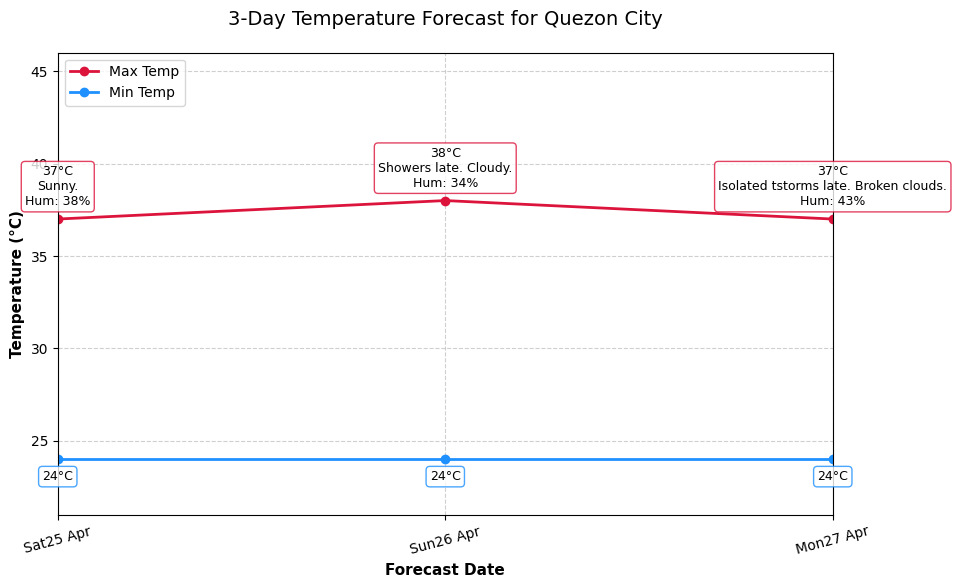

In [ ]:
#3 Forecast Data Visualizer (Animated)

import csv
import re
import sys
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def main():
    print("=== Forecast Data Visualizer ===")
    
    
    city_input = input("Enter city name (e.g., Quezon City): ").strip()
    
    days_input = input("Enter number of forecast days (<= 7) [default 3]: ").strip()
    if not days_input:
        days = 3
    else:
        try:
            days = int(days_input)
            
            days = max(1, min(days, 7))
        except ValueError:
            print("Invalid number entered. Defaulting to 3 days.")
            days = 3

    
    dates = []
    max_temps = []
    min_temps = []
    annotations_data = []

    try:
        with open('weather_data.csv', mode='r', encoding='utf-8') as file:
            reader = csv.reader(file)
            next(reader, None)  
            
            for row in reader:
                
                if len(row) < 4:
                    continue
                
                
                csv_city = row[1].strip()
                if csv_city.lower() != city_input.lower():
                    continue
                
                
                temp_str = row[3].strip()
                match = re.search(r'(\d+)\s*/\s*(\d+)', temp_str)
                
                if match:
                    max_t = int(match.group(1))
                    min_t = int(match.group(2))
                    date_str = row[2].strip()
                    
                   
                    condition = row[6].strip() if len(row) > 6 else ""
                    humidity = row[8].strip() if len(row) > 8 else ""
                    
                    dates.append(date_str)
                    max_temps.append(max_t)
                    min_temps.append(min_t)
                    annotations_data.append((condition, humidity))
                    
                    
                    if len(dates) == days:
                        break
                        
    except FileNotFoundError:
        print("\nError: 'weather_data.csv' not found. Please ensure it is in the same directory.")
        sys.exit(1)

    if not dates:
        print(f"\nNo forecast data found for '{city_input}'. Check the city name and try again.")
        sys.exit(1)

    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    
    ax.set_xlim(0, len(dates) - 1)
    
    
    all_temps = max_temps + min_temps
    ax.set_ylim(min(all_temps) - 3, max(all_temps) + 8)
    
    ax.set_xticks(range(len(dates)))
    ax.set_xticklabels(dates, rotation=15)
    ax.set_xlabel('Forecast Date', fontsize=11, fontweight='bold')
    ax.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
    ax.set_title(f'{days}-Day Temperature Forecast for {city_input.title()}', fontsize=14, pad=20)
    ax.grid(True, linestyle='--', alpha=0.6)

    
    line_max, = ax.plot([], [], marker='o', color='crimson', linewidth=2, label='Max Temp')
    line_min, = ax.plot([], [], marker='o', color='dodgerblue', linewidth=2, label='Min Temp')
    ax.legend(loc='upper left')

    
    drawn_annotations = []

    def init():
        line_max.set_data([], [])
        line_min.set_data([], [])
        return line_max, line_min

    def update(frame):
        
        x_data = list(range(frame))
        y_max = max_temps[:frame]
        y_min = min_temps[:frame]
        
        line_max.set_data(x_data, y_max)
        line_min.set_data(x_data, y_min)
        
        
        if frame > len(drawn_annotations):
            idx = frame - 1
            cond, hum = annotations_data[idx]
            
          
            ax.annotate(f"{max_temps[idx]}°C\n{cond}\nHum: {hum}", 
                        (idx, max_temps[idx]), 
                        textcoords="offset points", 
                        xytext=(0, 10), ha='center', fontsize=9, 
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.8))
            
          
            ax.annotate(f"{min_temps[idx]}°C", 
                        (idx, min_temps[idx]), 
                        textcoords="offset points", 
                        xytext=(0, -15), ha='center', fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="dodgerblue", alpha=0.8))
            
            drawn_annotations.append(idx)
            
        return line_max, line_min

  
    ani = FuncAnimation(fig, update, frames=range(1, len(dates) + 1),
                        init_func=init, blit=False, repeat=False, interval=600)

   
    output_filename = 'forecast_plot.gif'
    print(f"\nGenerating animation... (This may take a few seconds)")
    
    
    writer = PillowWriter(fps=1.5)
    ani.save(output_filename, writer=writer)
    
    print(f"Success! The animation has been saved as '{output_filename}'.")

if __name__ == "__main__":
    main()